<h2 align=center>Sentiment Classification: TF-IDF vs. spaCy Embeddings</h2>

### Task 1: Project Overview and Import Modules

We build a sentiment classifier for app reviews (negative / neutral / positive), and compare two text representations — **TF-IDF** and **spaCy word embeddings** — using the **same `tf.keras` classifier and the same preprocessing** for both, so the comparison is fair.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import re
import spacy
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline

nlp = spacy.load('en_core_web_md')
tf.random.set_seed(42)

I0000 00:00:1784721748.021455    1628 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784721749.475855    1628 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Task 2: Load and Explore the Dataset

In [2]:
data = pd.read_csv('all_data.csv')
data = data.dropna(subset=['review', 'sentiment']).reset_index(drop=True)
print("Number of reviews:", len(data))
data.head()

Number of reviews: 40516


,review,sentiment
0,Aditya Ingole Deaf,2
1,I love the app.! There is no issue but if u co...,1
2,"So hard to use. The web app failed, and the mo...",0
3,I hate that the app makes a sound every time s...,1
4,Useless at BSE star MF meet.voice too mych slo...,0


*Essential info about the labels*: `0 = negative`, `1 = neutral`, `2 = positive`.

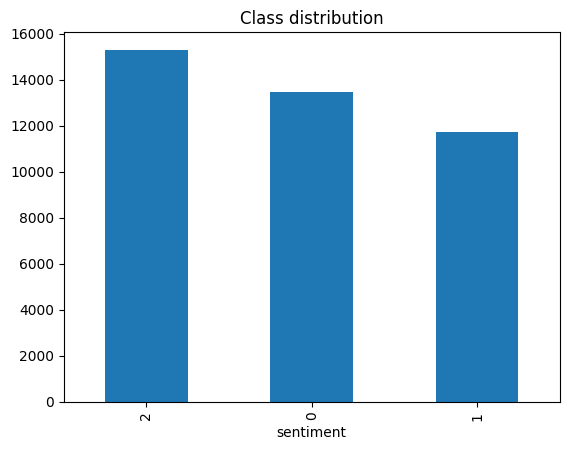

In [3]:
data['sentiment'].value_counts().plot(kind='bar', title='Class distribution')
plt.show()

### Task 3: Preprocess the Text

In [4]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['clean_text'] = data['review'].map(preprocess_text)
data = data[data['clean_text'].str.len() > 0].reset_index(drop=True)
print("Reviews after cleaning:", len(data))

Reviews after cleaning: 39804


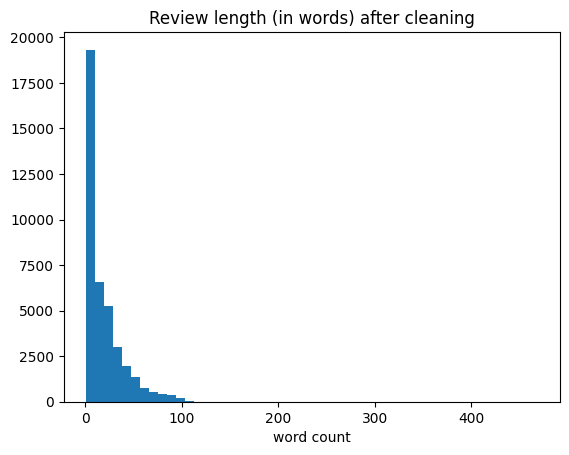

In [5]:
plt.hist(data['clean_text'].str.split().str.len(), bins=50)
plt.title('Review length (in words) after cleaning')
plt.xlabel('word count')
plt.show()

### Task 4: Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['clean_text'], data['sentiment'], test_size=0.2, random_state=42, stratify=data['sentiment']
)
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)
print("Train:", len(X_train), "Test:", len(X_test))

Train: 31843 Test: 7961


### Task 5: Build the TF-IDF Representation

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray().astype('float32')
X_test_tfidf = tfidf.transform(X_test).toarray().astype('float32')
X_train_tfidf.shape

(31843, 5000)

### Task 6: Build the spaCy Word Embedding Representation

In [8]:
def get_avg_vectors(texts):
    return np.array([doc.vector for doc in nlp.pipe(texts, batch_size=256)], dtype='float32')

X_train_emb = get_avg_vectors(X_train)
X_test_emb = get_avg_vectors(X_test)
X_train_emb.shape

(31843, 300)

### Task 7: Build and Compile the Classifier

The original sequence-labeling notebook builds a Bidirectional LSTM for token-level tagging on padded sequences. Since TF-IDF and averaged spaCy vectors are fixed-length (not sequences), the fair equivalent here is a feed-forward `tf.keras` network — we use the **same architecture** for both representations.

In [9]:
def build_model(input_dim, num_classes=3):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [10]:
model_tfidf = build_model(input_dim=X_train_tfidf.shape[1])
history_tfidf = model_tfidf.fit(X_train_tfidf, y_train_arr, epochs=8, batch_size=128,
                                 validation_split=0.1, verbose=0)
print("Final training accuracy:", history_tfidf.history['accuracy'][-1])

Final training accuracy: 0.8644706606864929


In [11]:
model_emb = build_model(input_dim=X_train_emb.shape[1])
history_emb = model_emb.fit(X_train_emb, y_train_arr, epochs=8, batch_size=128,
                             validation_split=0.1, verbose=0)
print("Final training accuracy:", history_emb.history['accuracy'][-1])

Final training accuracy: 0.5669271945953369


### Task 8: Evaluate and Compare

In [12]:
from sklearn.metrics import f1_score, classification_report

test_loss_tfidf, test_acc_tfidf = model_tfidf.evaluate(X_test_tfidf, y_test_arr, verbose=0)
pred_tfidf = np.argmax(model_tfidf.predict(X_test_tfidf, verbose=0), axis=1)
f1_tfidf = f1_score(y_test_arr, pred_tfidf, average='macro')
print(f"TF-IDF -> accuracy: {test_acc_tfidf:.4f}, macro F1: {f1_tfidf:.4f}")
print(classification_report(y_test_arr, pred_tfidf))

TF-IDF -> accuracy: 0.6851, macro F1: 0.6716
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      2657
           1       0.60      0.50      0.55      2302
           2       0.71      0.79      0.75      3002

    accuracy                           0.69      7961
   macro avg       0.67      0.67      0.67      7961
weighted avg       0.68      0.69      0.68      7961



In [13]:
test_loss_emb, test_acc_emb = model_emb.evaluate(X_test_emb, y_test_arr, verbose=0)
pred_emb = np.argmax(model_emb.predict(X_test_emb, verbose=0), axis=1)
f1_emb = f1_score(y_test_arr, pred_emb, average='macro')
print(f"spaCy embeddings -> accuracy: {test_acc_emb:.4f}, macro F1: {f1_emb:.4f}")
print(classification_report(y_test_arr, pred_emb))

spaCy embeddings -> accuracy: 0.5561, macro F1: 0.5127
              precision    recall  f1-score   support

           0       0.53      0.71      0.60      2657
           1       0.46      0.20      0.28      2302
           2       0.62      0.69      0.65      3002

    accuracy                           0.56      7961
   macro avg       0.53      0.53      0.51      7961
weighted avg       0.54      0.56      0.53      7961



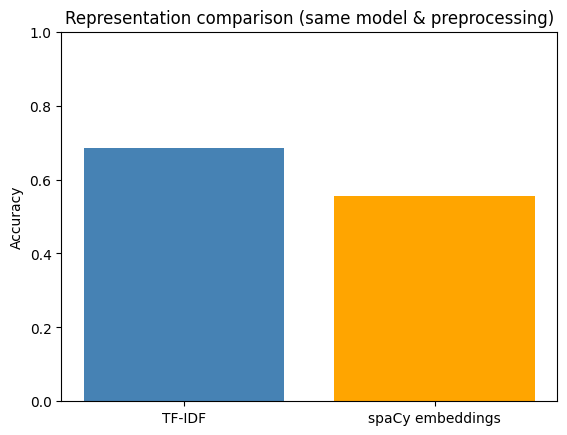

In [14]:
plt.bar(['TF-IDF', 'spaCy embeddings'], [test_acc_tfidf, test_acc_emb], color=['steelblue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Representation comparison (same model & preprocessing)')
plt.ylim(0, 1)
plt.show()

### Task 9: Predict on a New Review

In [15]:
def predict(text):
    clean = preprocess_text(text)
    pred_a = np.argmax(model_tfidf.predict(tfidf.transform([clean]).toarray().astype('float32'), verbose=0), axis=1)[0]
    pred_b = np.argmax(model_emb.predict(get_avg_vectors([clean]), verbose=0), axis=1)[0]
    mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return {'tfidf': mapping[pred_a], 'spacy': mapping[pred_b]}

predict("this is such a helpful app, thank you so much for the update")

{'tfidf': 'positive', 'spacy': 'positive'}

In [16]:
predict("worst update ever, nothing works anymore")

{'tfidf': 'negative', 'spacy': 'negative'}

## Conclusion

Using the exact same `tf.keras` classifier and the exact same preprocessing pipeline for both
representations, the bar chart above shows which representation, TF-IDF or spaCy embeddings, performed
better on this dataset of short, noisy, multilingual app reviews. Since the difference comes purely from
the representation (the model and preprocessing are identical), this is a genuine comparison of TF-IDF vs.
pretrained word embeddings for this specific domain.